#Iris dataset

The Iris dataset consists of 150 rows (or samples) representing three different species of iris flowers (Iris setosa, Iris versicolor, and Iris virginica), with 50 samples for each species. It contains 4 numerical attributes (features) measured in centimeters: sepal length, sepal width, petal length, and petal width. Each individual row in the dataset defines a single flower instance, detailing its four specific floral measurements along with its corresponding target species label.


A sepal is a part of a flower that forms the outer whorl of the floral structure, often referred to as the calyx. Its primary function is to protect the delicate flower bud while it is developing before it opens.

Structurally, sepals typically look like small, green, leaf-like structures located right beneath the petals, though in some plant species they can be brightly colored and resemble petals (known as petaloid sepals). In the context of the Iris dataset, sepal length and sepal width measure the dimensions of these protective outer leaf-like segments.

     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


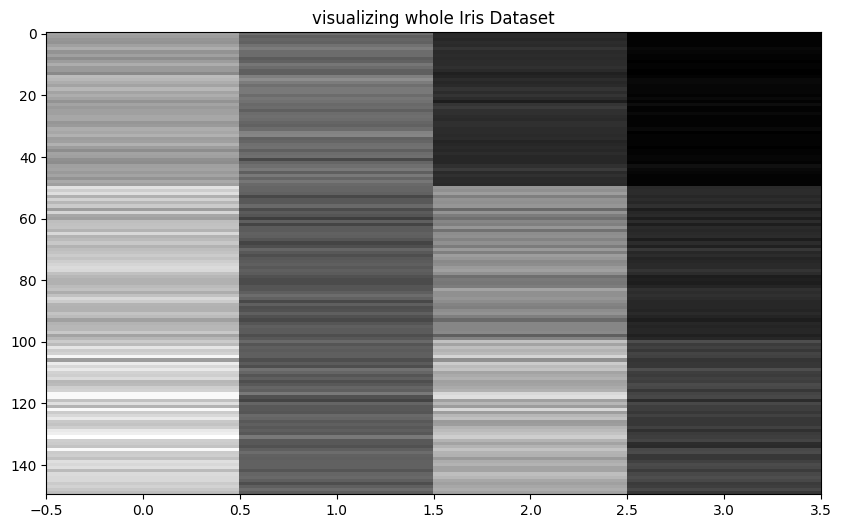

In [23]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.datasets import load_iris

# Calls the load_iris function from scikit-learn to load the Iris dataset into a container object
iris = load_iris()

# Creates a pandas DataFrame using the raw numerical feature values (iris.data) and labels the columns with the official feature names (iris.feature_names)
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

#visualize the data
print(iris_df)

# Visualize whole data
plt.figure(figsize=(10,6))
plt.title("visualizing whole Iris Dataset")
plt.imshow(iris_df, aspect='auto', cmap='gray')
plt.show()

##Computing different statistics Mean, Midean, Mode

Computing Mean, midean, mode for each columns (attributes/features, default axis in pandas dataframe or axis=0) of the dataset.

In [30]:
# 1. Calculate the mean (average) for each column
iris_mean = iris_df.mean()
print("--- Mean ---")
print(iris_mean)

# 2. Calculate the median (middle value) for each column
iris_median = iris_df.median()
print("\n--- Median ---")
print(iris_median)

# 3. Calculate the mode (most frequent value) for each column
iris_mode = iris_df.mode()
print("\n--- Mode ---")
print(iris_mode)

--- Mean ---
sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

--- Median ---
sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64

--- Mode ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.0               3.0                1.4               0.2
1                NaN               NaN                1.5               NaN


Computing the same Mean, mode midean on different axis i.e. row-wise.

**Note:** For some datasets row-wise computation sometimes doe'nt make any sense if they are of different categories like "gender", "age", "address"

In [31]:
# Computes the mean for each column (feature) - default behavior
column_means = iris_df.mean(axis=0)
print("Mean per feature (column):\n", column_means)

# Computes the mean for each individual flower (row) across its 4 features
row_means = iris_df.mean(axis=1)
print("\nMean per flower (row):\n", row_means.head())


# Column-wise median (default: axis=0): Finds the middle value for each feature column
column_medians = iris_df.median(axis=0)
print("Median per feature (column):\n", column_medians)

# Row-wise median (axis=1): Finds the middle value among the 4 measurements for each individual flower
row_medians = iris_df.median(axis=1)
print("\nMedian per flower (row):\n", row_medians.head())

# Column-wise mode (default: axis=0): Finds the most frequent value in each feature column
column_modes = iris_df.mode(axis=0)
print("Mode per feature (column):\n", column_modes)

# Row-wise mode (axis=1): Finds the most frequent value horizontally across a single row's 4 columns
row_modes = iris_df.mode(axis=1)
print("\nMode per flower (row):\n", row_modes.head())

Mean per feature (column):
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

Mean per flower (row):
 0    2.550
1    2.375
2    2.350
3    2.350
4    2.550
dtype: float64
Median per feature (column):
 sepal length (cm)    5.80
sepal width (cm)     3.00
petal length (cm)    4.35
petal width (cm)     1.30
dtype: float64

Median per flower (row):
 0    2.45
1    2.20
2    2.25
3    2.30
4    2.50
dtype: float64
Mode per feature (column):
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.0               3.0                1.4               0.2
1                NaN               NaN                1.5               NaN

Mode per flower (row):
      0    1    2    3
0  0.2  1.4  3.5  5.1
1  0.2  1.4  3.0  4.9
2  0.2  1.3  3.2  4.7
3  0.2  1.5  3.1  4.6
4  0.2  1.4  3.6  5.0


In [24]:
# Introduce missing values
np.random.seed(42) #Sets the random seed for NumPy to ensure reproducibility, ensuring that the exact same random values are generated every time the code runs.
missing_mask = np.random.rand(*iris_df.shape) < 0.1 #Generates a boolean mask of the exact same shape as iris_df filled with random floating-point numbers between 0 and 1, where roughly 10% of the elements are set to True.
iris_missing = iris_df.copy() #Creates an independent copy of the original DataFrame so that modifying iris_missing does not alter or corrupt the original iris_df
iris_missing[missing_mask] = np.nan  #Replaces the values in the DataFrame with np.nan (Not a Number) at all the positions where the boolean mask is True, successfully introducing missing data.

## Original Data with Missing Values

We can visualize the missing values in our data using the following plot:


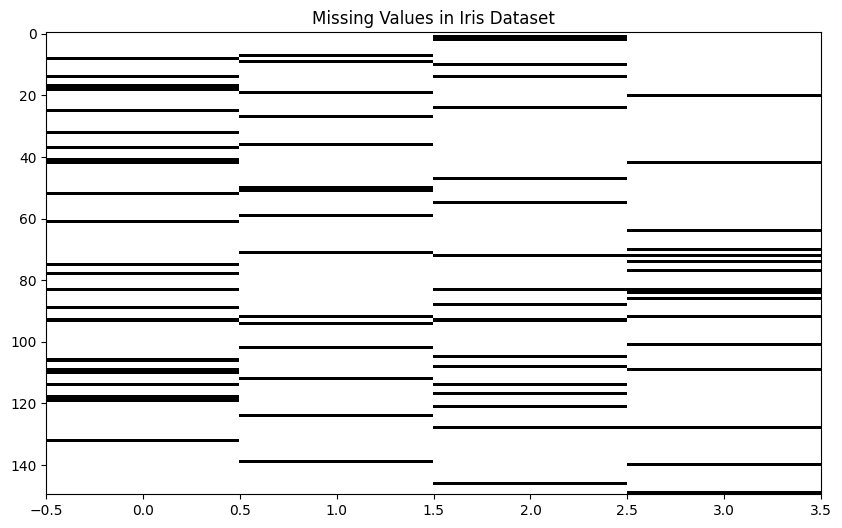

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,NaN,0.2
2,4.7,3.2,NaN,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [25]:
# Visualize missing data
plt.figure(figsize=(10,6))
plt.title("Missing Values in Iris Dataset")
plt.imshow(~iris_missing.isnull(), aspect='auto', cmap='gray')
plt.show()

# Display the first 5 rows with missing values
iris_missing.head()


In [26]:
iris_missing.isna().sum() # Returns the total count of missing (NaN) values for each column

,0
sepal length (cm),23
sepal width (cm),15
petal length (cm),18
petal width (cm),16


## Imputation using SimpleImputer

SimpleImputer fills missing values with a specified strategy such as mean, median, or most frequent value of the column.



#Missing Completely At Random (MCAR)

Definition: Data is said to be Missing Completely At Random (MCAR)
when the probability of missingness is the same for all observations.
In other words, the missingness is independent of both observed and
unobserved data.

Example: Suppose you have a dataset of student test scores and due to a
clerical error, random pages of the data are lost. The **missing** data is
likely MCAR as it **has no relationship with any other data**.

**Solution**: **Simple Imputer**, such as using the mean, median, or most
frequent value of the feature . You can also use a constant value.

In [27]:
# Simple Imputer
# Initialize the SimpleImputer object configured to replace missing values with the mean of each column
simple_imputer = SimpleImputer(strategy='mean')

# Compute the mean for each column (fit) and replace the missing (NaN) values with those means (transform), returning a NumPy array
iris_simple_imputed = simple_imputer.fit_transform(iris_missing)

# Convert the processed NumPy array back into a pandas DataFrame, restoring the original feature names as column headers
iris_simple_imputed_df = pd.DataFrame(iris_simple_imputed, columns=iris.feature_names)

# Display the first 5 rows after Simple Imputation
# Output the first 5 rows of the newly imputed DataFrame to verify that all missing values have been filled
iris_simple_imputed_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.400000,0.2
1,4.9,3.0,3.737879,0.2
2,4.7,3.2,3.737879,0.2
3,4.6,3.1,1.500000,0.2
4,5.0,3.6,1.400000,0.2


##Missing At Random (MAR)

Definition: Data is said to be Missing At Random (MAR) if the probability
of missingness is systematic and can be predicted by other observed
data, but not by the missing data itself.
Example: In a health survey, suppose females are less likely to report
their weight. The missingness of weight data is systematic and related to
the observed gender data but is not related to the weight data itself.

Solution:**K-Nearest Neighbors (KNN) Imputation**, **Iterative Imputer**, or
Regression Models. The other variables in the dataset predict the missing
variable.

**K-Nearest Neighbors (KNN)** Imputation works as follows:
1. Select the k nearest neighbors based on a distance metric.
2. Calculate the mean, median, mode, or weighted average value of the
K neighbours to fill the missing values.

**Iterative Imputer** works as follows:
1. Fill in missing values with a simple imputation (mean, median, etc)
2. Create a regression model to predict missing values in the selected
feature based on the values of the other features.
3. Impute missing values with the regressor.
4. Iterate through this process multiple times in a round-robin fashion
until the imputation values converge.

## Imputation using KNNImputer

KNNImputer fills missing values using the mean value from `n_neighbors` nearest neighbors found in the training set.


In [28]:
# Initialize the KNNImputer to look at the 5 nearest neighbors (using the average/mean value by default and do not support other strategies like median or mode) https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html
knn_imputer = KNNImputer(n_neighbors=5)

# .fit() learns the dataset distances and .transform() replaces missing (NaN) values with the average of those 5 neighbors, returning a NumPy array
iris_knn_imputed = knn_imputer.fit_transform(iris_missing)

# Convert the processed NumPy array back into a pandas DataFrame, restoring the original feature names as column headers
iris_knn_imputed_df = pd.DataFrame(iris_knn_imputed, columns=iris.feature_names)

# Display the first 5 rows after KNN Imputation
# Output the first 5 rows of the newly imputed DataFrame to inspect the filled values
iris_knn_imputed_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.5,0.2
2,4.7,3.2,1.5,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Imputation using IterativeImputer

IterativeImputer fills missing values by modeling each feature with missing values as a function of other features in a round-robin fashion.


In [29]:
# Initialize the IterativeImputer with a random state to ensure reproducible regression modeling rounds https://scikit-learn.org/stable/modules/generated/sklearn.impute.IterativeImputer.html
iterative_imputer = IterativeImputer(random_state=42)

# .fit() learns the relationships between features and .transform() iteratively models and fills in missing (NaN) values using round-robin regression, returning a NumPy array
iris_iterative_imputed = iterative_imputer.fit_transform(iris_missing)

# Convert the processed NumPy array back into a pandas DataFrame, restoring the original feature names as column headers
iris_iterative_imputed_df = pd.DataFrame(iris_iterative_imputed, columns=iris.feature_names)

# Display the first 5 rows after Iterative Imputation
iris_iterative_imputed_df.head()


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.400000,0.2
1,4.9,3.0,1.653994,0.2
2,4.7,3.2,1.361339,0.2
3,4.6,3.1,1.500000,0.2
4,5.0,3.6,1.400000,0.2
